# Upscaling (Super Resolution)

In [8]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets
import torchvision
import matplotlib.pyplot as plt
import random
import cv2 as cv
import torch.optim as optim
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchmetrics.image.psnr import PeakSignalNoiseRatio
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
import wandb

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data

In [10]:
def downscale_image(image: np.ndarray, scale: int = 4) -> np.ndarray:
    img = image.copy()
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    h, w = img.shape[:2]
    small_h = max(1, h // scale)
    small_w = max(1, w // scale)
    small = cv.resize(img, (small_w, small_h), interpolation=cv.INTER_AREA)
    return small

In [11]:
class DIV2InpaintingKDataset(Dataset):
    def __init__(self, data, normalize_transform=None, downscale=4):
        self.data = data
        self.normalize_transform = normalize_transform
        self.downscale = downscale

    def __getitem__(self, idx):
        pil_item = self.data[idx]
        pil_img = pil_item[0]
        if self.normalize_transform:
            hr = self.normalize_transform(pil_img)
        else:
            hr = transforms.ToTensor()(pil_img)
        hr_np = (hr.permute(1,2,0).numpy() * 255).astype(np.uint8)
        lr_up_np = downscale_image(hr_np, scale=self.downscale)
        lr_up = torch.from_numpy(lr_up_np).permute(2,0,1).float() / 255.0

        return hr, lr_up

    def __len__(self):
        return len(self.data)

In [ ]:
IMAGE_WIDTH = 256
IMAGE_HIGHT = 256
SQUARE_SIZE = 64

mean = 0.5
std = 0.5
dataset_train = datasets.ImageFolder(root="~/Projekty_WSL/SIGK-2025L/Project_1/dataset/DIV2K_train_HR/")
dataset_val = datasets.ImageFolder(root="~/Projekty_WSL/SIGK-2025L/Project_1/dataset/DIV2K_valid_HR/")

normalize_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize((IMAGE_HIGHT, IMAGE_WIDTH)),
    ]
)

BATCH_SIZE = 32
DOWNSCALE = IMAGE_HIGHT//SQUARE_SIZE

In [ ]:
original_dataset = dataset_train
train_image_dataset = DIV2InpaintingKDataset(dataset_train, normalize_transform=normalize_transform, downscale=DOWNSCALE)
val_image_dataset = DIV2InpaintingKDataset(dataset_val, normalize_transform=normalize_transform, downscale=DOWNSCALE)

train_dataloader = DataLoader(train_image_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_image_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Modele
### Esrgan - Generator

In [ ]:
class ResidualDenseBlock(nn.Module):
    def __init__(self, channels, growth_channels=32, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, growth_channels, kernel_size, padding=kernel_size//2)
        self.conv2 = nn.Conv2d(channels + growth_channels, growth_channels, kernel_size, padding=kernel_size//2)
        self.conv3 = nn.Conv2d(channels + 2*growth_channels, channels, kernel_size, padding=kernel_size//2)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.scale = 0.2

    def forward(self, x):
        out1 = self.lrelu(self.conv1(x))
        out2 = self.lrelu(self.conv2(torch.cat([x, out1], dim=1)))
        out3 = self.conv3(torch.cat([x, out1, out2], dim=1))
        return x + out3 * self.scale

class RRDB(nn.Module):
    def __init__(self, channels, growth_channels=32):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(channels, growth_channels)
        self.rdb2 = ResidualDenseBlock(channels, growth_channels)
        self.rdb3 = ResidualDenseBlock(channels, growth_channels)
        self.scale = 0.2

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return x + out * self.scale

class Esrgan(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, num_features=64, num_blocks=8):
        super().__init__()
        
        self.conv_first = nn.Conv2d(input_channels, num_features, kernel_size=3, padding=1)
        
        self.body = nn.Sequential(*[RRDB(num_features) for _ in range(num_blocks)])
        self.trunk_conv = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        
        self.upsample1 = nn.Sequential(
            nn.Conv2d(num_features, num_features * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.upsample2 = nn.Sequential(
            nn.Conv2d(num_features, num_features * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.upsample3 = nn.Sequential(
            nn.Conv2d(num_features, num_features * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        self.conv_hr = nn.Conv2d(num_features, num_features, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_features, output_channels, 3, 1, 1)
        

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.body(fea)
        fea = self.trunk_conv(trunk) + fea 
        
        fea = self.upsample1(fea)
        fea = self.upsample2(fea)
        fea = self.upsample3(fea)
        
        out = self.conv_last(self.conv_hr(fea))
        return torch.sigmoid(out)

### VGG19

In [ ]:
class VGGFeatureExtractor(nn.Module):
    def __init__(self, feature_layer=13, use_bn=False):
        super().__init__()
        if use_bn:
            vgg19 = torchvision.models.vgg19_bn(weights='VGG19_BN_Weights.DEFAULT')
        else:
            vgg19 = torchvision.models.vgg19(weights='VGG19_Weights.DEFAULT')
            
        self.features = nn.Sequential(*vgg19.features[:feature_layer]) 
        
        for param in self.features.parameters():
            param.requires_grad = False
            
    def forward(self, x):
        return self.features(x)

VGG_LOSS_WEIGHT = 0.005

### Dyscriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, in_nc, nf=64):
        super().__init__()

        self.conv0 = nn.Sequential(
            nn.Conv2d(in_nc, nf, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.conv1 = self._make_layer(nf, nf * 2, stride=2) 
        self.conv2 = self._make_layer(nf * 2, nf * 4, stride=1)
        self.conv3 = self._make_layer(nf * 4, nf * 8, stride=2)
        self.conv4 = self._make_layer(nf * 8, nf * 8, stride=1)
        self.conv5 = self._make_layer(nf * 8, nf * 16, stride=2)
        
        self.final_conv = nn.Sequential(
            nn.Conv2d(nf * 16, nf * 8, kernel_size=1, stride=1, padding=0),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(nf * 8, 1, kernel_size=1, stride=1, padding=0)
        )

    def _make_layer(self, in_nc, out_nc, stride):
        return nn.Sequential(
            nn.Conv2d(in_nc, out_nc, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_nc),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        x = self.conv0(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        return self.final_conv(x)

## Training

In [17]:
model = EsrganLite(num_features=64, num_blocks=8).to(device)

In [18]:
criterion_mse = nn.MSELoss().to(device)

In [19]:
discriminator = Discriminator(in_nc=3).to(device)

In [ ]:
DISC_LEARNING_RATE = 0.0002 
optimizer_D = optim.Adam(discriminator.parameters(), lr=DISC_LEARNING_RATE)
scheduler_D = optim.lr_scheduler.ExponentialLR(optimizer_D, gamma=0.82)
 
criterion_L1 = nn.L1Loss().to(device)
criterion_MSE = nn.MSELoss().to(device)
VGG_FEAT_EXTRACTOR = VGGFeatureExtractor().to(device)
VGG_LOSS_WEIGHT = 0.005
GAN_LOSS_WEIGHT = 0.001


def upscale_loss_generator(original, upscaled, discriminator, ssim):
    pixel_loss = criterion_L1(upscaled, original) + 0.8 * (1.0 - ssim(upscaled, original))

    with torch.no_grad():
        original_features = VGG_FEAT_EXTRACTOR(original).detach()
    upscaled_features = VGG_FEAT_EXTRACTOR(upscaled)
    perceptual_loss = criterion_MSE(upscaled_features, original_features)
    
    fake_prediction = discriminator(upscaled)
    target_real = torch.ones_like(fake_prediction, device=device)
    adversarial_loss = criterion_MSE(fake_prediction, target_real)

    total_loss = pixel_loss + VGG_LOSS_WEIGHT * perceptual_loss + GAN_LOSS_WEIGHT * adversarial_loss
    
    return total_loss, pixel_loss.item(), perceptual_loss.item(), adversarial_loss.item()

def upscale_loss_discriminator(original, upscaled, discriminator):
    real_prediction = discriminator(original)
    target_real = torch.ones_like(real_prediction, device=device)
    loss_real = criterion_MSE(real_prediction, target_real)
    
    fake_prediction = discriminator(upscaled.detach())
    target_fake = torch.zeros_like(fake_prediction, device=device)
    loss_fake = criterion_MSE(fake_prediction, target_fake)
    
    total_loss = (loss_real + loss_fake) / 2
    
    return total_loss

In [ ]:
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

LEARNING_RATE = 0.0002
DISC_LEARNING_RATE = 0.0002
NUMBER_OF_EPOCHS = 200

optimizer_G = optim.Adam(model.parameters(), lr=LEARNING_RATE)
optimizer_D = optim.Adam(discriminator.parameters(), lr=DISC_LEARNING_RATE)
scheduler_G = optim.lr_scheduler.ExponentialLR(optimizer_G, gamma=0.82)
scheduler_D = optim.lr_scheduler.ExponentialLR(optimizer_D, gamma=0.82)
sism_criterion = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device) 

run = wandb.init(
    project="SIGK-project-1_ESRGAN",
    config={
        "learning_rate_G": LEARNING_RATE,
        "learning_rate_D": DISC_LEARNING_RATE,
        "epochs": NUMBER_OF_EPOCHS,
        "loss_weights": f"L1+SSIM+VGG({VGG_LOSS_WEIGHT})+GAN({GAN_LOSS_WEIGHT})",
        "model": "ESRGAN Full",
        "patience": patience,
    },
)

for epoch in range(NUMBER_OF_EPOCHS):

    print(f"--- Started Epoch {epoch+1}/{NUMBER_OF_EPOCHS} ---")
    model.train()
    discriminator.train()
    
    accumulated_G_loss = 0.0
    accumulated_D_loss = 0.0
    accumulated_pixel_loss = 0.0
    accumulated_perceptual_loss = 0.0
    accumulated_adversarial_loss = 0.0
    accumulated_train_psnr = 0.0
    accumulated_train_ssim = 0.0

    for original_images, low_quality_images in train_dataloader:
        original_images = original_images.to(device)
        low_quality_images = low_quality_images.to(device)

        optimizer_G.zero_grad()
        upscaled_images = model(low_quality_images)
            
        total_G_loss, pixel_loss, perceptual_loss, adversarial_loss = upscale_loss_generator(
            original_images, upscaled_images, discriminator, sism_criterion
        )
        
        total_G_loss.backward()
        optimizer_G.step()

        optimizer_D.zero_grad()
        D_loss = upscale_loss_discriminator(original_images, upscaled_images, discriminator)
        
        D_loss.backward()
        optimizer_D.step()

        accumulated_G_loss += total_G_loss.item()
        accumulated_D_loss += D_loss.item()
        accumulated_pixel_loss += pixel_loss
        accumulated_perceptual_loss += perceptual_loss
        accumulated_adversarial_loss += adversarial_loss
        accumulated_train_ssim += sism_criterion(upscaled_images.detach(), original_images.detach()).item()
        accumulated_train_psnr += psnr_metric(upscaled_images.detach(), original_images.detach()).item()
        
    len_dl = len(train_dataloader)
    avg_G_loss = accumulated_G_loss / len_dl
    avg_D_loss = accumulated_D_loss / len_dl
    
    # Validation
    model.eval()
    discriminator.eval()
    accumulated_val_loss = 0.0
    accumulated_val_psnr = 0.0
    accumulated_val_ssim = 0.0
    
    with torch.no_grad():
        for original_val, low_quality_val in val_dataloader:
            original_val = original_val.to(device)
            low_quality_val = low_quality_val.to(device)

            upscaled_val = model(low_quality_val)

            val_loss, _, _, _ = upscale_loss_generator(
                original_val, upscaled_val, discriminator, sism_criterion
            )
            
            accumulated_val_loss += val_loss.item()
            accumulated_val_ssim += sism_criterion(upscaled_val, original_val).item()
            accumulated_val_psnr += psnr_metric(upscaled_val, original_val).item()
            
    avg_val_loss = accumulated_val_loss / len(val_dataloader)

    run.log({
        "epoch": epoch + 1,
        "train/G_total_loss": avg_G_loss,
        "train/D_loss": avg_D_loss,
        "train/G_pixel_loss": accumulated_pixel_loss / len_dl,
        "train/G_perceptual_loss": accumulated_perceptual_loss / len_dl,
        "train/G_adversarial_loss": accumulated_adversarial_loss / len_dl,
        "train/psnr": accumulated_train_psnr / len_dl,
        "train/ssim": accumulated_train_ssim / len_dl,
        "val/G_total_loss": avg_val_loss,
        "val/psnr": accumulated_val_psnr / len(val_dataloader),
        "val/ssim": accumulated_val_ssim / len(val_dataloader),
    })
    
    print(f"Train G Loss: {avg_G_loss:.6f} | Train D Loss: {avg_D_loss:.6f} | Val G Loss: {avg_val_loss:.6f}")
    
    # Check Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.jit.script(model.cpu()).save(f"esrgan_full_best_{SQUARE_SIZE}x{SQUARE_SIZE}.pt")
        model.to(device) 
        print("Model Generatora zapisany: nowa najlepsza strata walidacyjna.")
    else:
        epochs_no_improve += 1
        print(f"Brak poprawy straty walidacyjnej: {epochs_no_improve}/{patience}")
        if epochs_no_improve >= patience:
            print(f"!!! Wczesne Zatrzymanie: Osiągnięto patience ({patience}) !!!")
            break
            
    if epoch % 10 == 0:
        scheduler_G.step()
        scheduler_D.step()

run.finish()

## Evaluation

In [ ]:
model_path = "~/Projekty_WSL/SIGK-2025L/Project_1/esrgan_full_best_64x64.pt"
model = torch.jit.load(model_path).to(device)

In [86]:
def get_image_scores(original_image: np.ndarray, altered_image: np.ndarray):
  original_image = torch.from_numpy(original_image).permute(2, 0, 1).unsqueeze(0).float() / 255.0
  altered_image = torch.from_numpy(altered_image).permute(2, 0, 1).unsqueeze(0).float() / 255.0
  return {
      "LPIPS" : LearnedPerceptualImagePatchSimilarity(net_type='squeeze')(original_image, altered_image),
      "PSNR" : PeakSignalNoiseRatio(1.0)(original_image, altered_image),
      "SSIM": StructuralSimilarityIndexMeasure()(original_image, altered_image)
  }

def measure_dataset_difference(original_images: list[np.ndarray], altered_images: list[np.ndarray]):
  results = pd.DataFrame([get_image_scores(og, alt) for og, alt in zip(original_images, altered_images)]).astype(float)
  results = results[results.SSIM > 0.1]
  return results.mean()

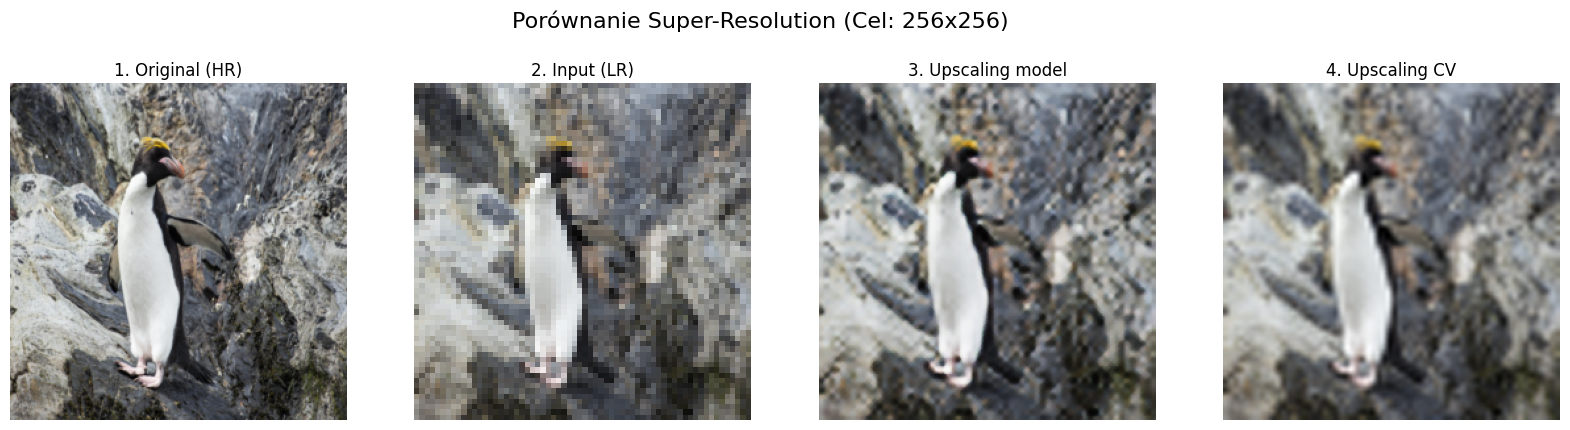

In [ ]:
TARGET_SIZE_LR = (SQUARE_SIZE, SQUARE_SIZE)
TARGET_SIZE_HR = (256, 256)
test_dataloader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=True)

original_tensor, model_input_tensor = next(iter(val_dataloader))
id_photo = random.randint(1, 50)

model_input_gpu = model_input_tensor.to(device)
model.to(device)
model.eval()
with torch.no_grad():
    model_output_tensor = model(model_input_gpu)

original_np = original_tensor.cpu().numpy()[id_photo].transpose(1, 2, 0)
model_input_np = model_input_tensor.cpu().numpy()[id_photo].transpose(1, 2, 0)
model_output_np = model_output_tensor.cpu().numpy()[id_photo].transpose(1, 2, 0)

if original_np.max() <= 1.0:
    original_np = (original_np * 255).astype(np.uint8)
if model_input_np.max() <= 1.0:
    model_input_np = (model_input_np * 255).astype(np.uint8)
if model_output_np.max() <= 1.0:
    model_output_np = (model_output_np * 255).astype(np.uint8)


img_LR_esrgan = cv.resize(
    original_np, 
    TARGET_SIZE_LR, 
    interpolation=cv.INTER_AREA
)

benchmark_cubic_np = cv.resize(
    img_LR_esrgan, 
    TARGET_SIZE_HR, 
    interpolation=cv.INTER_CUBIC
)


plt.figure(figsize=(20, 5))
plt.suptitle("Porównanie Super-Resolution (Cel: 256x256)", fontsize=16)

plt.subplot(1, 4, 1)
plt.title("1. Original (HR)")
plt.imshow(original_np)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("2. Input (LR)")
plt.imshow(model_input_np)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("3. Upscaling model")
plt.imshow(model_output_np)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("4. Upscaling CV")
plt.imshow(benchmark_cubic_np)
plt.axis('off')

plt.show()

In [ ]:
def get_sr_results_for_dataset_with_cnn(raw_dataset):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    processed_dataset = DIV2InpaintingKDataset(raw_dataset, normalize_transform=normalize_transform, downscale=DOWNSCALE) 
    
    test_dataloader = DataLoader(processed_dataset, batch_size=BATCH_SIZE, shuffle=False)
    original_hr_images = []
    upscaled_sr_images = []

    model.eval()

    with torch.no_grad():
        for original_hr, input_lr_up in test_dataloader:
            original_hr_images.extend(original_hr.numpy().transpose(0, 2, 3, 1) * 255)

            input_lr_up = input_lr_up.to(device)
            upscaled_output = model(input_lr_up)
            
            upscaled_sr_images.append(upscaled_output.cpu().numpy().transpose(0, 2, 3, 1) * 255)

    upscaled_sr_images_flat = [img for batch in upscaled_sr_images for img in batch]
    return original_hr_images, upscaled_sr_images_flat

In [ ]:
def get_sr_results_for_dataset_with_opencv(raw_dataset):
    original_hr_images_np = []
    opencv_sr_images_np = []
    processed_dataset = DIV2InpaintingKDataset(raw_dataset, normalize_transform=normalize_transform, downscale=DOWNSCALE) 
    
    test_dataloader = DataLoader(processed_dataset, batch_size=BATCH_SIZE, shuffle=False)

    for original_hr_tensor, _ in test_dataloader:

        original_hr_np = original_hr_tensor.cpu().numpy()[0].transpose(1, 2, 0)
        if original_hr_np.max() <= 1.0:
            original_hr_np = (original_hr_np * 255).astype(np.uint8)
        else:
            original_hr_np = original_hr_np.astype(np.uint8)
            
        original_hr_images_np.append(original_hr_np)

        img_lr_np = cv.resize(
            original_hr_np, 
            (SQUARE_SIZE, SQUARE_SIZE), 
            interpolation=cv.INTER_AREA 
        )

        opencv_sr_np = cv.resize(
            img_lr_np, 
            (IMAGE_HIGHT, IMAGE_WIDTH), 
            interpolation=cv.INTER_CUBIC 
        )
        
        opencv_sr_images_np.append(opencv_sr_np)

    return original_hr_images_np, opencv_sr_images_np

In [ ]:
def measure_sr_model_performance(dataset: Dataset, sr_method, wariations_per_image=1):
    original_images = []
    output_images = []
    with torch.no_grad():
        for _ in range(wariations_per_image):
            original_hr, output_sr = sr_method(dataset)
            original_images.extend(original_hr)
            output_images.extend(output_sr)
            
    return measure_dataset_difference(original_images, output_images)

In [91]:
measure_sr_model_performance(dataset_val, get_sr_results_for_dataset_with_cnn, wariations_per_image=1)

LPIPS     0.203861
PSNR     24.131986
SSIM      0.719342
dtype: float64

In [92]:
measure_sr_model_performance(dataset_val, get_sr_results_for_dataset_with_opencv, wariations_per_image=1)

LPIPS     0.343118
PSNR     22.179651
SSIM      0.587140
dtype: float64